Author: Yashasvi Moon

Adapted for cosmicAI by Padma Venkatraman

# K-Neighbor Classifier

In this notebook, we use a K-Nearest Neighbors (KNN) classifier to identify QBS galaxies using photometry. KNN is a distance-based classifier. A galaxy is classified based on the labels of its nearest neighboring galaxies in feature space.

**Because KNN depends on distances between data points, feature scaling is important before training the model**


## Notebook Goals

By the end of this notebook, we will:

1. Split the data into training and testing sets
2. Learn about scaling features and why it 
3. Train sci-kit K-Neighbor classifier
4. Run a grid search with several hyperparameter combos on the KNN to evaluate which gives best result. **Run your OWN combinations and use the model with hyperparameters that you think performs best!**
5. Evaluate model performance
6. Use your trained model to identify likely QBS candidates in a larger non-labelled catalog

## Import Libraries

In [12]:
import numpy as np
import pandas as pd
from astropy.io import fits
from sklearn import metrics
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer,f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


## Load the Labeled Dataset

We begin with the cleaned and labeled dataset created in the previous notebook. This dataset contains photometric color features and QBS/non-QBS labels.

In [2]:
df = pd.read_csv('labelled_dataset.csv')

## Select Features and Target Labels

The model uses photometric colors and redshift as input features. The target label indicates whether a galaxy satisfies the QBS selection criteria.

In [ ]:
list_of_interesting_properties = [...]
X= df[list_of_interesting_properties]

Y= df['labels']

## Scale Features

KNN is distance-based, so features with larger numeric ranges can dominate the distance calculation and similarly the ones with small ranges may be ignored. So we need to standardize the features before training the model.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = ...
X_scaled = ...

## Split into Training and Testing Sets


We split the labelled dataset into training and testing subsets. The training set is used for model fitting and hyperparameter tuning, while the test set is held out for final evaluation.
The `stratify` option preserves the class balance between QBS and non-QBS galaxies.

In [ ]:
x_train, x_test, y_train, y_test = ...


## Define the Scoring Metric

Because QBS galaxies are rare, overall accuracy is not the best metric. Instead, we use the F1 score for the QBS class (for the class labelled 1). F1 score is the harmonic mean of purity and completeness. We want to maximise purity of the sample (while not completely disregarding the completeness) since we do not want to waste our limited spectroscopic tools for follow-up on the less confident detections.

In [ ]:
my_scoring = ...

## Define the Hyperparameter Search Space
KNN performance depends on choices such as the number of neighbors, distance weighting, distance metric, and nearest-neighbor search algorithm.

**You are encouraged to play around and change the numbers below while referring to `scikit_learn` -> `KNeighborsClassifier` to understand how these play a role.**


In [ ]:
n_neighbors = ...
weights = ...
algorithm = ...
leaf_size = ...
p = ...

knn_grid = {
    "n_neighbors": n_neighbors,
    "weights": weights,
    "algorithm": algorithm,
    "leaf_size": leaf_size,
    "p": p
}

knn_grid

{'n_neighbors': [2, 4, 8, 12, 18, 26, 32, 38],
 'weights': ['uniform', 'distance'],
 'algorithm': ['auto', 'kd_tree', 'ball_tree'],
 'leaf_size': [5, 15, 30, 50],
 'p': [1, 2]}

## Run Randomized Search Cross-Validation

**Please change n_iter. Right now it is too small, it will only run 10 iterations with 2 cross-validations each. You do not want it to be too high either as it will take a long time to run. Discuss and come up with a reasonable number for n_iter  Can refer to `RandomizedSearchCV` in `scikit_learn`**

In [8]:
knn = KNeighborsClassifier()

knn_random = RandomizedSearchCV(estimator=knn, param_distributions=knn_grid,
    n_iter=2, cv=3, verbose=2, random_state=42,
    n_jobs=-1, scoring=my_scoring)

knn_random.fit(x_train, y_train)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV] END algorithm=auto, leaf_size=50, n_neighbors=4, p=2, weights=uniform; total time=   5.1s
[CV] END algorithm=auto, leaf_size=50, n_neighbors=4, p=2, weights=uniform; total time=   5.2s
[CV] END algorithm=auto, leaf_size=50, n_neighbors=4, p=2, weights=uniform; total time=   5.2s
[CV] END algorithm=ball_tree, leaf_size=30, n_neighbors=38, p=1, weights=uniform; total time=  25.8s
[CV] END algorithm=ball_tree, leaf_size=30, n_neighbors=38, p=1, weights=uniform; total time=  26.6s
[CV] END algorithm=ball_tree, leaf_size=30, n_neighbors=38, p=1, weights=uniform; total time=  26.8s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'algorithm': ['auto', 'kd_tree', ...], 'leaf_size': [5, 15, ...], 'n_neighbors': [2, 4, ...], 'p': [1, 2], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(f..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ve

## Evaluate the Optimized KNN Model

We evaluate the best KNN classifier on the held-out test set using classification metrics and a confusion matrix.

Best parameters found:
{'weights': 'uniform', 'p': 2, 'n_neighbors': 4, 'leaf_size': 50, 'algorithm': 'auto'}
              precision    recall  f1-score   support

       Other       0.97      1.00      0.98     34636
         QBS       0.66      0.15      0.25      1190

    accuracy                           0.97     35826
   macro avg       0.82      0.58      0.62     35826
weighted avg       0.96      0.97      0.96     35826



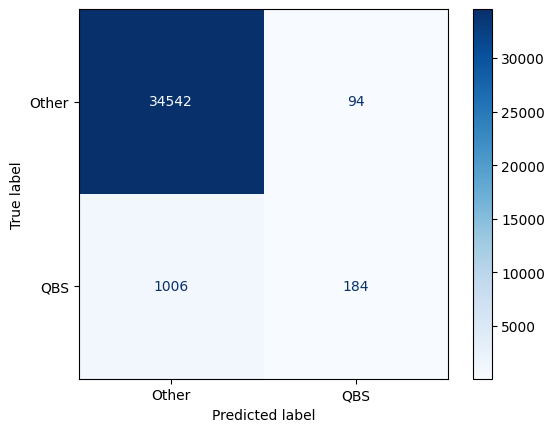

In [15]:
best_knn = knn_random.best_estimator_

y_pred = best_knn.predict(x_test)

print("Best parameters found:")
print(knn_random.best_params_)

print(classification_report(y_test, y_pred, target_names=["Other", "QBS"]))

cm = confusion_matrix(y_test, y_pred)
# plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Other", "QBS"])
# display the plot
disp.plot(cmap=plt.cm.Blues)


## Optional: Adjust the classification threshold like we did in RF, test different probabilities, add different classifications (not just "Other" and "QBS")


              precision    recall  f1-score   support

       Other       0.99      0.93      0.96     34636
         QBS       0.25      0.65      0.36      1190

    accuracy                           0.92     35826
   macro avg       0.62      0.79      0.66     35826
weighted avg       0.96      0.92      0.94     35826



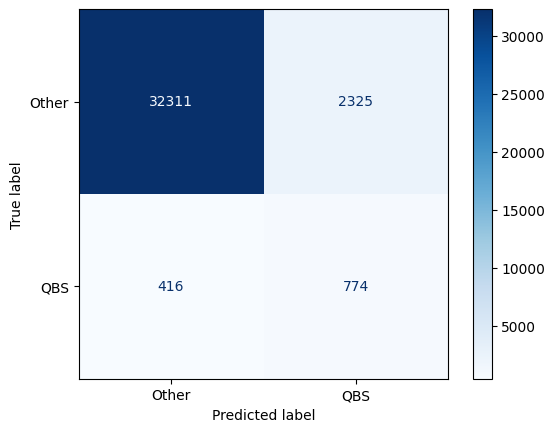

## Apply the KNN Classifier to the Photometric Catalog

After evaluating the optimized (maybe the optional section too) of KNN, we apply it to the larger photometric catalog to identify likely QBS galaxy candidates.

NOTE: This catalog contains both previously seen galaxies and galaxies without spectroscopic classifications. The classifier predicts which galaxies are likely QBS using **only** photometric information. I have already filtered this catalog and only included sources within z =0.3.

**The process for this will be similar in nb 01, the only difference when comparing to this step with RF is because KNN is distance-based, the full catalog must be scaled using the same scaler that was fit on the training data.**


TODO: How do these results change if you add more classes, not just "Other" and "QBS"? What if you added more properties?